In [1]:
import os, pathlib
print(pathlib.Path(r"C:\Users\karol\.kaggle\kaggle.json").exists())

True


In [2]:
%pip install kaggle --quiet

Note: you may need to restart the kernel to use updated packages.


In [3]:
!kaggle datasets download -d berkeleyearth/climate-change-earth-surface-temperature-data -p data --unzip

'kaggle' is not recognized as an internal or external command,
operable program or batch file.


In [4]:
import sys
!{sys.executable} -m kaggle datasets download -d berkeleyearth/climate-change-earth-surface-temperature-data -p data --unzip

C:\Users\karol\AppData\Local\Programs\Python\Python314\python.exe: No module named kaggle.__main__; 'kaggle' is a package and cannot be directly executed


In [5]:
!pip install kaggle --upgrade --user


'pip' is not recognized as an internal or external command,
operable program or batch file.


In [6]:
!pip install kaggle --upgrade --user

'pip' is not recognized as an internal or external command,
operable program or batch file.


In [7]:
import os
import sys
print(sys.executable)
!where kaggle

C:\Users\karol\AppData\Local\Programs\Python\Python314\python.exe


INFO: Could not find files for the given pattern(s).


In [8]:
# Jeśli jeszcze nie masz:
# %pip install kaggle --quiet

from kaggle.api.kaggle_api_extended import KaggleApi
import pathlib

# uwaga: plik C:\Users\karol\.kaggle\kaggle.json musi istnieć (u Ciebie już jest)
api = KaggleApi()
api.authenticate()  # użyje kaggle.json

# pobierz i rozpakuj do podfolderu "data"
path = pathlib.Path("data")
path.mkdir(exist_ok=True)
api.dataset_download_files(
    "berkeleyearth/climate-change-earth-surface-temperature-data",
    path=str(path),
    unzip=True
)

print("Pobrano do:", path.resolve())


Dataset URL: https://www.kaggle.com/datasets/berkeleyearth/climate-change-earth-surface-temperature-data
Pobrano do: C:\Users\karol\data


In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

csv_path = "data/GlobalLandTemperaturesByMajorCity.csv"
df = pd.read_csv(csv_path)

# info + braki
df.info()
print("\nBraki na kolumnę:\n", df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 239177 entries, 0 to 239176
Data columns (total 7 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   dt                             239177 non-null  object 
 1   AverageTemperature             228175 non-null  float64
 2   AverageTemperatureUncertainty  228175 non-null  float64
 3   City                           239177 non-null  object 
 4   Country                        239177 non-null  object 
 5   Latitude                       239177 non-null  object 
 6   Longitude                      239177 non-null  object 
dtypes: float64(2), object(5)
memory usage: 12.8+ MB

Braki na kolumnę:
 dt                                   0
AverageTemperature               11002
AverageTemperatureUncertainty    11002
City                                 0
Country                              0
Latitude                             0
Longitude                         

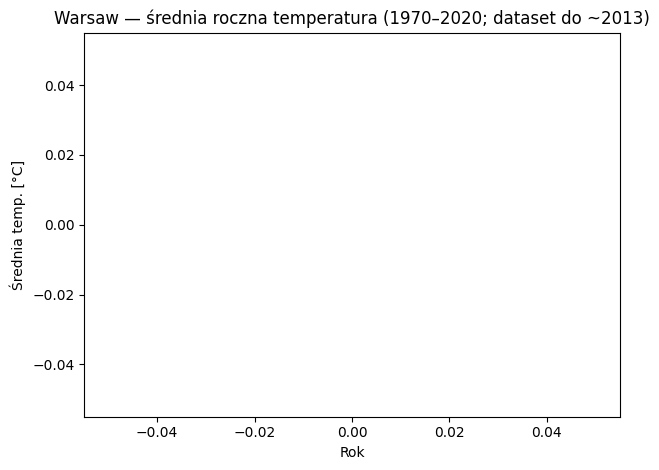

Średnia 1970–1990: nan °C
Średnia 2000–2020: nan °C  (uwaga: w tym zbiorze brak lat >2013)
Różnica (2000–2020 minus 1970–1990): nan °C


In [10]:
# przygotowanie danych dla Warsaw 1970–2020
df["dt"] = pd.to_datetime(df["dt"], errors="coerce")
df_city = df[df["City"].str.lower() == "warsaw"].copy()
df_city = df_city.rename(columns={"AverageTemperature":"temp",
                                 "AverageTemperatureUncertainty":"temp_unc"})
df_city = df_city[(df_city["dt"].dt.year >= 1970) & (df_city["dt"].dt.year <= 2020)]
df_city = df_city.dropna(subset=["temp"]).drop_duplicates()
df_city["year"] = df_city["dt"].dt.year

# średnia roczna i wykres
annual = df_city.groupby("year", observed=False)["temp"].mean().reset_index()

sns.lineplot(data=annual, x="year", y="temp")
plt.title("Warsaw — średnia roczna temperatura (1970–2020; dataset do ~2013)")
plt.xlabel("Rok"); plt.ylabel("Średnia temp. [°C]"); plt.tight_layout(); plt.show()

# porównanie okresów
mean_70_90 = annual.query("1970 <= year <= 1990")["temp"].mean()
mean_00_20 = annual.query("2000 <= year <= 2020")["temp"].mean()
print(f"Średnia 1970–1990: {mean_70_90:.2f} °C")
print(f"Średnia 2000–2020: {mean_00_20:.2f} °C  (uwaga: w tym zbiorze brak lat >2013)")
print(f"Różnica (2000–2020 minus 1970–1990): {mean_00_20 - mean_70_90:.2f} °C")


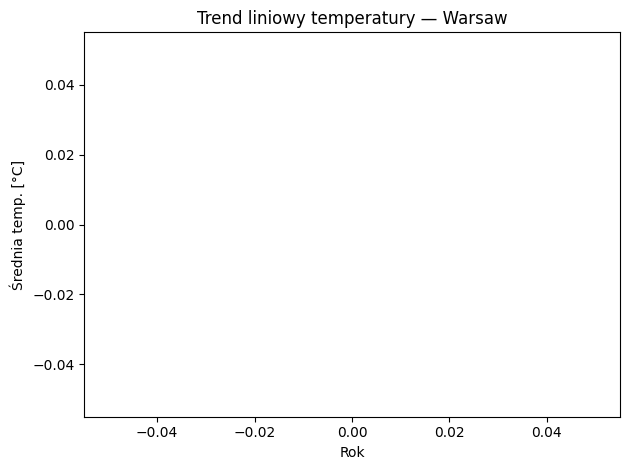

In [11]:
# linia trendu (regresja)
sns.regplot(data=annual, x="year", y="temp", scatter_kws={"alpha":0.6})
plt.title("Trend liniowy temperatury — Warsaw")
plt.xlabel("Rok"); plt.ylabel("Średnia temp. [°C]"); plt.tight_layout(); plt.show()


In [12]:
import os
os.environ["HTTP_PROXY"]  = "http://proxy_host:proxy_port"
os.environ["HTTPS_PROXY"] = "http://proxy_host:proxy_port"

from kaggle.api.kaggle_api_extended import KaggleApi
api = KaggleApi()
api.authenticate()
api.dataset_download_files(
    "berkeleyearth/climate-change-earth-surface-temperature-data",
    path="data",
    unzip=True
)


Dataset URL: https://www.kaggle.com/datasets/berkeleyearth/climate-change-earth-surface-temperature-data


InvalidURL: Failed to parse: http://proxy_host:proxy_port

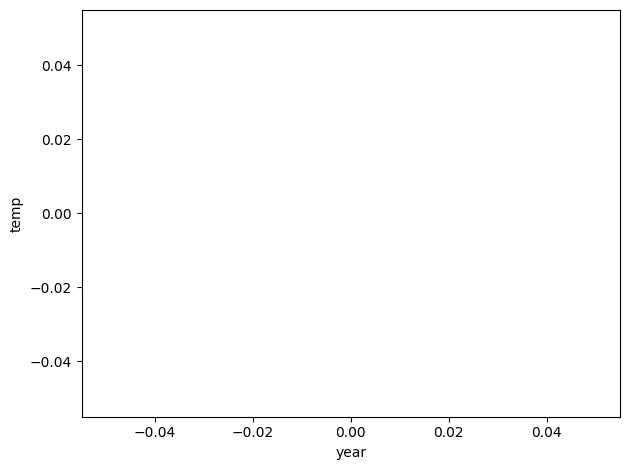

1970–1990: nan °C, 2000–2020: nan °C, różnica: nan °C


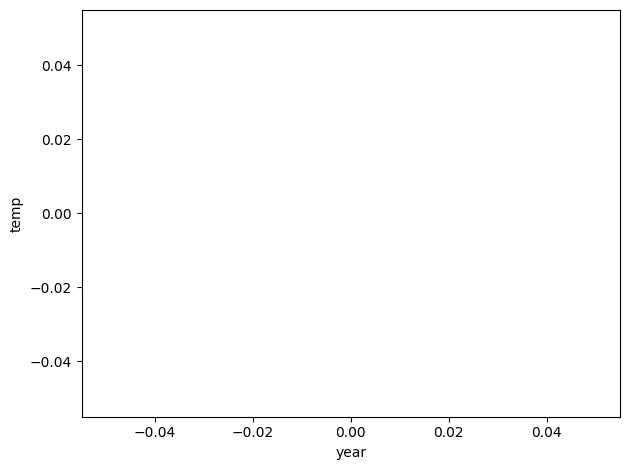

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("data/GlobalLandTemperaturesByMajorCity.csv")
df["dt"] = pd.to_datetime(df["dt"], errors="coerce")

city = "Warsaw"
df_city = (df[df["City"].str.lower()==city.lower()]
           .rename(columns={"AverageTemperature":"temp",
                            "AverageTemperatureUncertainty":"temp_unc"})
           .query("1970 <= dt.dt.year <= 2020")
           .dropna(subset=["temp"])
           .drop_duplicates())
df_city["year"] = df_city["dt"].dt.year

annual = df_city.groupby("year", observed=False)["temp"].mean().reset_index()

sns.lineplot(data=annual, x="year", y="temp"); plt.tight_layout(); plt.show()

m70_90 = annual.query("1970<=year<=1990")["temp"].mean()
m00_20 = annual.query("2000<=year<=2020")["temp"].mean()
print(f"1970–1990: {m70_90:.2f} °C, 2000–2020: {m00_20:.2f} °C, różnica: {m00_20-m70_90:.2f} °C")

sns.regplot(data=annual, x="year", y="temp", scatter_kws={"alpha":0.6}); plt.tight_layout(); plt.show()
